In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

# Project root
PROJECT_ROOT = Path.cwd().parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.dataloader.loader import load_session

In [2]:
DATA_PATH = PROJECT_ROOT / "dataset" / "dhdata" / "sample_1.csv"

df, metadata = load_session(DATA_PATH)

print("Metadata:")
for key, value in metadata.items():
    print(f"{key}: {value}")

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Metadata:
file_name: sample_1.csv
file_path: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\dataset\dhdata\sample_1.csv
file_size_bytes: 4301683
n_rows: 117828
n_columns: 6

Shape:
(117828, 6)

Columns:
['Time (real)', 'IR Value raw', 'Unnamed: 2', 'Time (s)', 'Label', 'IR Value filtered']


,Time (real),IR Value raw,Unnamed: 2,Time (s),Label,IR Value filtered
0,4/4/2025 12:18,97422,NaN,2.63,0,-18
1,4/4/2025 12:18,97202,NaN,2.65,0,-223
2,4/4/2025 12:18,97118,NaN,2.67,0,-288
3,4/4/2025 12:18,97108,NaN,2.69,0,-279
4,4/4/2025 12:18,97106,NaN,2.71,0,-263


In [3]:
time = df["Time (s)"].to_numpy()
ppg_raw = df["IR Value raw"].to_numpy()
labels = df["Label"].to_numpy()

print(f"Time samples : {len(time)}")
print(f"PPG samples  : {len(ppg_raw)}")
print(f"Label samples: {len(labels)}")

print(f"\nTime range: {time[0]:.2f} -> {time[-1]:.2f} s")
print(f"PPG range : {ppg_raw.min()} -> {ppg_raw.max()}")
print(f"Labels    : {sorted(set(labels))}")

Time samples : 117828
PPG samples  : 117828
Label samples: 117828

Time range: 2.63 -> 2359.17 s
PPG range : 89195 -> 99781
Labels    : [0, 1]


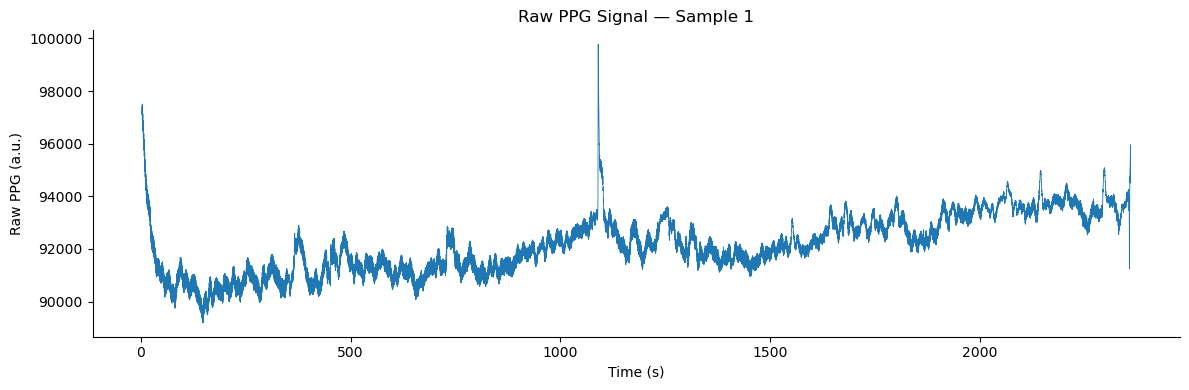

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time, ppg_raw, linewidth=0.6)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Raw PPG (a.u.)")
ax.set_title("Raw PPG Signal — Sample 1")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

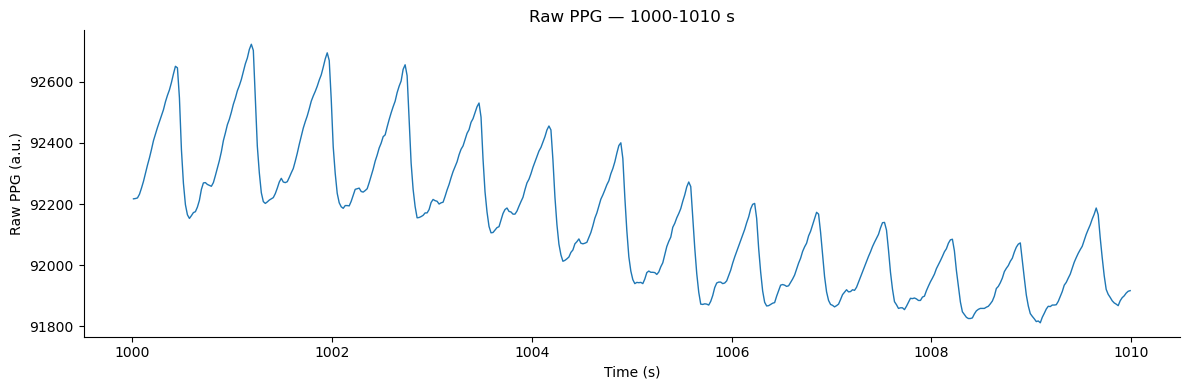

In [5]:
start_s = 1000
duration_s = 10

mask = (time >= start_s) & (time <= start_s + duration_s)

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(time[mask], ppg_raw[mask], linewidth=1)

ax.set_xlabel("Time (s)")
ax.set_ylabel("Raw PPG (a.u.)")
ax.set_title(f"Raw PPG — {start_s}-{start_s + duration_s} s")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
label_counts = pd.Series(labels).value_counts().sort_index()

awake_count = int(label_counts.get(0, 0))
drowsy_count = int(label_counts.get(1, 0))
total_count = len(labels)

awake_pct = awake_count / total_count * 100
drowsy_pct = drowsy_count / total_count * 100

print(f"Awake : {awake_count:,} samples ({awake_pct:.2f}%)")
print(f"Drowsy: {drowsy_count:,} samples ({drowsy_pct:.2f}%)")

Awake : 77,805 samples (66.03%)
Drowsy: 40,023 samples (33.97%)


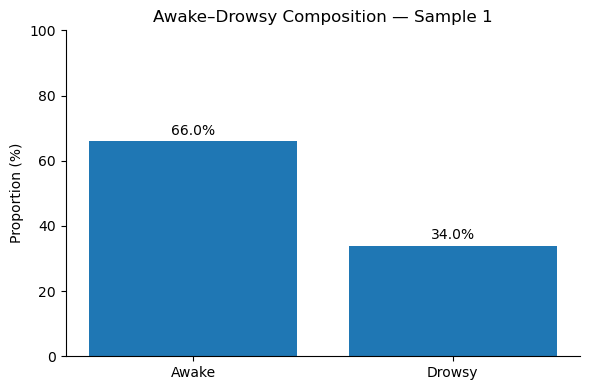

In [7]:
states = ["Awake", "Drowsy"]
percentages = [awake_pct, drowsy_pct]

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(states, percentages)

ax.set_ylabel("Proportion (%)")
ax.set_ylim(0, 100)
ax.set_title("Awake–Drowsy Composition — Sample 1")

for bar, value in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [8]:
# Segmented loader test 1: Basic loading
import numpy as np

from src.dataloader.loader import load_segmented_session

SEGMENTED_DIR = PROJECT_ROOT / "segmentated_data" / "dhdata"
SEGMENTED_SESSION = "sample_5.csv"
PRIMARY_SIZES = {60, 120, 180}

segmented_windows, segmented_metadata = load_segmented_session(
    SEGMENTED_SESSION
)
assert set(segmented_windows) == PRIMARY_SIZES

basic_rows = []
for window_size, batch in segmented_windows.items():
    metadata_count = int(
        (segmented_metadata["window_size_s"] == window_size).sum()
    )
    shape_matches = batch["signal"].shape[0] == metadata_count
    assert shape_matches
    basic_rows.append({
        "Window (s)": window_size,
        "Signal shape": str(batch["signal"].shape),
        "Metadata rows": metadata_count,
        "Shape matches": shape_matches,
    })

basic_loading_passed = True
display(pd.DataFrame(basic_rows).style.hide(axis="index"))

Window (s),Signal shape,Metadata rows,Shape matches
60,"(49, 1500)",49,True
120,"(22, 3000)",22,True
180,"(12, 4500)",12,True


In [9]:
# Segmented loader test 2: Window-size selection
selection_cases = [
    ("60", 60, {60}),
    ("60 and 180", [60, 180], {60, 180}),
    ("Default", None, PRIMARY_SIZES),
]
selection_rows = []
for case_name, requested, expected in selection_cases:
    selected_windows, _ = load_segmented_session(
        SEGMENTED_SESSION, window_sizes=requested
    )
    returned = set(selected_windows)
    passed = returned == expected
    assert passed
    selection_rows.append({
        "Case": case_name,
        "Expected": sorted(expected),
        "Returned": sorted(returned),
        "Pass": passed,
    })

window_selection_passed = True
display(pd.DataFrame(selection_rows).style.hide(axis="index"))

Case,Expected,Returned,Pass
60,[60],[60],True
60 and 180,"[60, 180]","[60, 180]",True
Default,"[60, 120, 180]","[60, 120, 180]",True


In [10]:
# Segmented loader test 3: Representation modes
raw_windows, _ = load_segmented_session(
    SEGMENTED_SESSION, representation="raw"
)
processed_windows, _ = load_segmented_session(
    SEGMENTED_SESSION, representation="processed"
)
both_windows, _ = load_segmented_session(
    SEGMENTED_SESSION,
    representation="both",
    stationarity_only=False,
)

representation_rows = []
for window_size in sorted(PRIMARY_SIZES):
    raw_has_signal = "signal" in raw_windows[window_size]
    processed_has_signal = "signal" in processed_windows[window_size]
    both = both_windows[window_size]
    both_has_signals = "raw" in both and "processed" in both
    shapes_match = both["raw"].shape == both["processed"].shape
    separate_flags = (
        "stationarity_pass_raw" in both
        and "stationarity_pass_processed" in both
    )
    assert raw_has_signal and processed_has_signal
    assert both_has_signals and shapes_match and separate_flags
    representation_rows.append({
        "Window (s)": window_size,
        "Raw filtered": len(raw_windows[window_size]["signal"]),
        "Processed filtered": len(
            processed_windows[window_size]["signal"]
        ),
        "Both unfiltered": len(both["raw"]),
        "Both shapes match": shapes_match,
        "Separate flags": separate_flags,
    })

representation_passed = True
display(pd.DataFrame(representation_rows).style.hide(axis="index"))

Window (s),Raw filtered,Processed filtered,Both unfiltered,Both shapes match,Separate flags
60,32,49,54,True,True
120,13,22,25,True,True
180,10,12,14,True,True


In [11]:
# Segmented loader test 4: Label filtering
label_cases = [
    ("Code 0", 0, 0),
    ("Code 1", 1, 1),
    ("Awake name", "awake", 0),
    ("Drowsy name", "drowsy", 1),
]
label_rows = []
for case_name, requested_label, expected_label in label_cases:
    filtered_windows, filtered_metadata = load_segmented_session(
        SEGMENTED_SESSION, labels=requested_label
    )
    arrays_match = all(
        np.all(batch["label"] == expected_label)
        for batch in filtered_windows.values()
    )
    metadata_matches = bool(
        (filtered_metadata["label"] == expected_label).all()
    )
    assert arrays_match and metadata_matches
    label_rows.append({
        "Case": case_name,
        "Expected label": expected_label,
        "Returned windows": len(filtered_metadata),
        "Arrays match": arrays_match,
        "Metadata matches": metadata_matches,
    })

label_filtering_passed = True
display(pd.DataFrame(label_rows).style.hide(axis="index"))

Case,Expected label,Returned windows,Arrays match,Metadata matches
Code 0,0,56,True,True
Code 1,1,27,True,True
Awake name,0,56,True,True
Drowsy name,1,27,True,True


In [12]:
# Segmented loader test 5: Stationarity filtering
stationarity_rows = []
filtered_counts = {"raw": {}, "processed": {}}
for representation in ("raw", "processed"):
    unfiltered, _ = load_segmented_session(
        SEGMENTED_SESSION,
        representation=representation,
        stationarity_only=False,
    )
    filtered, _ = load_segmented_session(
        SEGMENTED_SESSION,
        representation=representation,
        stationarity_only=True,
    )
    for window_size in sorted(PRIMARY_SIZES):
        before = len(unfiltered[window_size]["signal"])
        after = len(filtered[window_size]["signal"])
        pass_flags = filtered[window_size]["stationarity_pass"]
        assert after <= before
        assert pass_flags.all()
        filtered_counts[representation][window_size] = after
        stationarity_rows.append({
            "Signal": representation.capitalize(),
            "Window (s)": window_size,
            "Unfiltered": before,
            "Filtered": after,
            "Rejected": before - after,
            "All retained pass": bool(pass_flags.all()),
        })

representation_counts_differ = any(
    filtered_counts["raw"][size]
    != filtered_counts["processed"][size]
    for size in PRIMARY_SIZES
)
assert representation_counts_differ
stationarity_filtering_passed = True
display(pd.DataFrame(stationarity_rows).style.hide(axis="index"))
print(f"Raw/Processed counts differ: {representation_counts_differ}")

Signal,Window (s),Unfiltered,Filtered,Rejected,All retained pass
Raw,60,54,32,22,True
Raw,120,25,13,12,True
Raw,180,14,10,4,True
Processed,60,54,49,5,True
Processed,120,25,22,3,True
Processed,180,14,12,2,True


Raw/Processed counts differ: True


In [13]:
# Segmented loader test 6: Alignment and integrity
integrity_windows, _ = load_segmented_session(
    SEGMENTED_SESSION,
    representation="both",
    stationarity_only=False,
)
archive_path = SEGMENTED_DIR / "sample_5.npz"
integrity_rows = []
with np.load(archive_path, allow_pickle=False) as archive:
    for window_size, batch in integrity_windows.items():
        count = len(batch["raw"])
        aligned_lengths = all(
            len(batch[key]) == count
            for key in (
                "processed",
                "window_id",
                "label",
                "start_time",
                "end_time",
                "row_index",
            )
        )
        expected_samples = int(round(window_size * batch["fs"]))
        sample_count_matches = batch["raw"].shape[1] == expected_samples
        row_indices = batch["row_index"]
        raw_matches = np.array_equal(
            batch["raw"], archive[f"{window_size}/raw"][row_indices]
        )
        processed_matches = np.array_equal(
            batch["processed"],
            archive[f"{window_size}/processed"][row_indices],
        )
        sample_offsets = np.arange(expected_samples) / batch["fs"]
        reconstructed_time = (
            batch["start_time"][:, None] + sample_offsets
        )
        expected_end = reconstructed_time[:, -1]
        end_error = np.abs(expected_end - batch["end_time"])
        max_end_error = float(end_error.max()) if end_error.size else 0.0
        end_tolerance = 0.002 * window_size
        end_matches = bool(max_end_error <= end_tolerance)
        assert aligned_lengths and sample_count_matches
        assert raw_matches and processed_matches and end_matches
        integrity_rows.append({
            "Window (s)": window_size,
            "Windows": count,
            "Aligned lengths": aligned_lengths,
            "Sample count": sample_count_matches,
            "NPZ row lookup": raw_matches and processed_matches,
            "Max end error (s)": max_end_error,
            "End tolerance (s)": end_tolerance,
            "End time matches": end_matches,
        })

integrity_passed = True
display(pd.DataFrame(integrity_rows).style.format({
    "Max end error (s)": "{:.4f}",
    "End tolerance (s)": "{:.3f}",
}).hide(axis="index"))

Window (s),Windows,Aligned lengths,Sample count,NPZ row lookup,Max end error (s),End tolerance (s),End time matches
60,54,True,True,True,0.0760,0.120,True
120,25,True,True,True,0.1415,0.240,True
180,14,True,True,True,0.2080,0.360,True


In [14]:
# Segmented loader test 7: Global consistency
segments_index = pd.read_csv(SEGMENTED_DIR / "segments_index.csv")
session_names = sorted(segments_index["session"].unique())
global_counts = {60: 0, 120: 0, 180: 0}
raw_pass_total = 0
processed_pass_total = 0
for session_name in session_names:
    all_windows, all_metadata = load_segmented_session(
        session_name,
        representation="both",
        stationarity_only=False,
    )
    _, raw_metadata = load_segmented_session(
        session_name, representation="raw"
    )
    _, processed_metadata = load_segmented_session(
        session_name, representation="processed"
    )
    for window_size in PRIMARY_SIZES:
        global_counts[window_size] += len(all_windows[window_size]["raw"])
    raw_pass_total += len(raw_metadata)
    processed_pass_total += len(processed_metadata)
    assert len(all_metadata) == sum(
        len(all_windows[size]["raw"]) for size in PRIMARY_SIZES
    )

expected_counts = {60: 951, 120: 432, 180: 254}
assert global_counts == expected_counts
assert sum(global_counts.values()) == 1637
assert raw_pass_total == 1398
assert processed_pass_total == 1544
global_consistency_passed = True

global_summary = pd.DataFrame({
    "Window (s)": [60, 120, 180, "Total"],
    "Expected": [951, 432, 254, 1637],
    "Returned": [
        global_counts[60],
        global_counts[120],
        global_counts[180],
        sum(global_counts.values()),
    ],
})
display(global_summary.style.hide(axis="index"))
print(f"Sessions checked: {len(session_names)}")
print(f"Raw stationarity pass: {raw_pass_total:,}")
print(f"Processed stationarity pass: {processed_pass_total:,}")

Window (s),Expected,Returned
60,951,951
120,432,432
180,254,254
Total,1637,1637


Sessions checked: 20
Raw stationarity pass: 1,398
Processed stationarity pass: 1,544


In [15]:
# Segmented loader test 8: Edge cases
def check_exception(case_name, expected_type, call):
    """Run one expected-exception case."""
    try:
        call()
    except expected_type as exc:
        return {
            "Case": case_name,
            "Expected": expected_type.__name__,
            "Received": type(exc).__name__,
            "Message": str(exc),
            "Pass": True,
        }
    except Exception as exc:
        return {
            "Case": case_name,
            "Expected": expected_type.__name__,
            "Received": type(exc).__name__,
            "Message": str(exc),
            "Pass": False,
        }
    return {
        "Case": case_name,
        "Expected": expected_type.__name__,
        "Received": "No exception",
        "Message": "",
        "Pass": False,
    }


edge_case_rows = [
    check_exception(
        "Missing session",
        FileNotFoundError,
        lambda: load_segmented_session("missing_session"),
    ),
    check_exception(
        "Unsupported window size",
        ValueError,
        lambda: load_segmented_session(SEGMENTED_SESSION, window_sizes=240),
    ),
    check_exception(
        "Invalid label",
        ValueError,
        lambda: load_segmented_session(SEGMENTED_SESSION, labels="sleep"),
    ),
    check_exception(
        "Invalid representation",
        ValueError,
        lambda: load_segmented_session(
            SEGMENTED_SESSION, representation="filtered"
        ),
    ),
    check_exception(
        "Both with stationarity filter",
        ValueError,
        lambda: load_segmented_session(
            SEGMENTED_SESSION, representation="both"
        ),
    ),
    check_exception(
        "Empty window sizes",
        ValueError,
        lambda: load_segmented_session(SEGMENTED_SESSION, window_sizes=[]),
    ),
    check_exception(
        "Empty labels",
        ValueError,
        lambda: load_segmented_session(SEGMENTED_SESSION, labels=[]),
    ),
]
edge_case_summary = pd.DataFrame(edge_case_rows)
edge_cases_passed = bool(edge_case_summary["Pass"].all())
assert edge_cases_passed
display(edge_case_summary.style.hide(axis="index"))

Case,Expected,Received,Message,Pass
Missing session,FileNotFoundError,FileNotFoundError,Session archive does not exist: C:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\Nonlinear-Time-Series-Analysis\phase1\segmentated_data\dhdata\missing_session.npz,True
Unsupported window size,ValueError,ValueError,"Unsupported window size 240; choose from (60, 120, 180)",True
Invalid label,ValueError,ValueError,Unsupported label: sleep,True
Invalid representation,ValueError,ValueError,"representation must be 'raw', 'processed', or 'both'",True
Both with stationarity filter,ValueError,ValueError,Use stationarity_only=False with representation='both'; filter each representation with its own pass flag,True
Empty window sizes,ValueError,ValueError,window_sizes cannot be empty,True
Empty labels,ValueError,ValueError,labels cannot be empty,True


In [16]:
# Segmented loader final validation summary
loader_validation = pd.DataFrame({
    "Test": [
        "Basic loading",
        "Window-size selection",
        "Representation modes",
        "Label filtering",
        "Stationarity filtering",
        "Alignment and integrity",
        "Global consistency",
        "Edge cases",
    ],
    "Pass": [
        basic_loading_passed,
        window_selection_passed,
        representation_passed,
        label_filtering_passed,
        stationarity_filtering_passed,
        integrity_passed,
        global_consistency_passed,
        edge_cases_passed,
    ],
})
ready_to_freeze = bool(loader_validation["Pass"].all())
assert ready_to_freeze
display(loader_validation.style.hide(axis="index"))
print(
    f"Loader validation passed: "
    f"{int(loader_validation['Pass'].sum())} / {len(loader_validation)}"
)

Test,Pass
Basic loading,True
Window-size selection,True
Representation modes,True
Label filtering,True
Stationarity filtering,True
Alignment and integrity,True
Global consistency,True
Edge cases,True


Loader validation passed: 8 / 8


# Tổng kết kết quả kiểm thử segmented loader

## Kết quả tổng thể

| Nhóm kiểm thử | Nội dung chính | Kết quả |
| --- | --- | --- |
| Basic loading | Trả đủ key 60/120/180 s; signal và metadata cùng số hàng | Pass |
| Window-size selection | Kiểm tra `60`, `[60, 180]` và `None` | Pass |
| Representation | Kiểm tra Raw, Processed và Both | Pass |
| Label filtering | Kiểm tra `0`, `1`, `awake`, `drowsy` | Pass |
| Stationarity filtering | So sánh trước/sau lọc riêng cho Raw và Processed | Pass |
| Alignment/integrity | Kiểm tra metadata, shape, NPZ lookup và reconstructed time | Pass |
| Global consistency | Chạy loader trên toàn bộ 20 session | Pass |
| Edge cases | Bảy trường hợp đầu vào không hợp lệ | Pass |
| **Tổng** | **8 nhóm kiểm thử** | **8/8 Pass** |

## Basic loading với `sample_5.csv`

Default arguments sử dụng Processed PPG và chỉ giữ stationarity-pass window.

| Window (s) | Signal shape | Metadata rows | Shape khớp |
| ---: | --- | ---: | --- |
| 60 | `(49, 1500)` | 49 | True |
| 120 | `(22, 3000)` | 22 | True |
| 180 | `(12, 4500)` | 12 | True |

Window-size selection trả đúng `{60}`, `{60, 180}` và `{60, 120, 180}` cho ba input tương ứng.

## Representation và stationarity filtering

| Window (s) | Raw pass | Processed pass | Both unfiltered | Raw/Processed cùng shape | Hai pass flag riêng |
| ---: | ---: | ---: | ---: | --- | --- |
| 60 | 32 | 49 | 54 | True | True |
| 120 | 13 | 22 | 25 | True | True |
| 180 | 10 | 12 | 14 | True | True |

| Signal | Window (s) | Unfiltered | Filtered | Rejected | Tất cả retained pass |
| --- | ---: | ---: | ---: | ---: | --- |
| Raw | 60 | 54 | 32 | 22 | True |
| Raw | 120 | 25 | 13 | 12 | True |
| Raw | 180 | 14 | 10 | 4 | True |
| Processed | 60 | 54 | 49 | 5 | True |
| Processed | 120 | 25 | 22 | 3 | True |
| Processed | 180 | 14 | 12 | 2 | True |

Raw và Processed trả key `signal` trong single-representation mode. Chế độ Both giữ `raw`, `processed`, `stationarity_pass_raw` và `stationarity_pass_processed` riêng.

## Label filtering

| Input | Label mong đợi | Số window trả về | Signal labels đúng | Metadata labels đúng |
| --- | ---: | ---: | --- | --- |
| `0` | 0 | 56 | True | True |
| `1` | 1 | 27 | True | True |
| `awake` | 0 | 56 | True | True |
| `drowsy` | 1 | 27 | True | True |

## Alignment và integrity

| Window (s) | Windows | Metadata lengths | Sample count | NPZ row lookup | Max end error (s) | Tolerance (s) | End time khớp |
| ---: | ---: | --- | --- | --- | ---: | ---: | --- |
| 60 | 54 | True | True | True | 0,0760 | 0,120 | True |
| 120 | 25 | True | True | True | 0,1415 | 0,240 | True |
| 180 | 14 | True | True | True | 0,2080 | 0,360 | True |

Các trường `window_id`, `label`, `start_time`, `end_time` và `row_index` có cùng số hàng với signal. `row_index` truy xuất đúng Raw và Processed trong archive; reconstructed time phù hợp với `end_time` trong tolerance đã định nghĩa.

## Global consistency

| Metric | Expected | Returned |
| --- | ---: | ---: |
| Window 60 s | 951 | 951 |
| Window 120 s | 432 | 432 |
| Window 180 s | 254 | 254 |
| Tổng unfiltered window | 1.637 | 1.637 |
| Raw stationarity pass | 1.398 | 1.398 |
| Processed stationarity pass | 1.544 | 1.544 |
| Session được kiểm tra | 20 | 20 |

## Edge cases

| Trường hợp | Exception mong đợi | Exception nhận được | Kết quả |
| --- | --- | --- | --- |
| Session không tồn tại | `FileNotFoundError` | `FileNotFoundError` | Pass |
| Window size không hỗ trợ | `ValueError` | `ValueError` | Pass |
| Label không hợp lệ | `ValueError` | `ValueError` | Pass |
| Representation không hợp lệ | `ValueError` | `ValueError` | Pass |
| Both với `stationarity_only=True` | `ValueError` | `ValueError` | Pass |
| `window_sizes=[]` | `ValueError` | `ValueError` | Pass |
| `labels=[]` | `ValueError` | `ValueError` | Pass |

Toàn bộ **16/16 code cell** trong notebook chạy thành công và không có runtime error.
